# Proyek Klasifikasi Gambar: New Plant Diseases Dataset
- **Nama:** Dimas januar pradana
- **Email:** pradanadimas534@gmail.com
- **ID Dicoding:** CACC525D6Y0145

## Import Semua Packages/Library yang Digunakan

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import os
import kagglehub
import shutil


from tqdm import tqdm as tq
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

## Data Preparation

### Data Loading

In [4]:
path = kagglehub.dataset_download(
    "vipoooool/new-plant-diseases-dataset"
)
print("Path dataset:", path)

train_path = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "train"
)

val_path = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "valid"
)



# Direktori baru untuk dataset gabungan
combined_dir = "plant_diseases/dataset"
os.makedirs(combined_dir, exist_ok=True)

# Gabungkan train + valid ke combined_dir
# =====================
for folder in [train_path, val_path]:
    for label in os.listdir(folder):
        label_path = os.path.join(folder, label)
        if os.path.isdir(label_path):
            dest_label = os.path.join(combined_dir, label)
            os.makedirs(dest_label, exist_ok=True)
            for img_name in os.listdir(label_path):
                src = os.path.join(label_path, img_name)
                dst = os.path.join(dest_label, img_name)
                if not os.path.exists(dst):
                    shutil.copy2(src, dst)

print("Penggabungan selesai!")
# Cek jumlah gambar per kelas
total = 0
for label in sorted(os.listdir(combined_dir)):
    label_path = os.path.join(combined_dir, label)
    if os.path.isdir(label_path):
        jumlah = len(os.listdir(label_path))
        total += jumlah
        print(f"{label}: {jumlah} gambar")

print(f"\nTotal semua gambar: {total}")
print(f"Total kelas: {len(os.listdir(combined_dir))}")

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path dataset: /kaggle/input/new-plant-diseases-dataset
Penggabungan selesai!
Apple___Apple_scab: 2520 gambar
Apple___Black_rot: 2484 gambar
Apple___Cedar_apple_rust: 2200 gambar
Apple___healthy: 2510 gambar
Blueberry___healthy: 2270 gambar
Cherry_(including_sour)___Powdery_mildew: 2104 gambar
Cherry_(including_sour)___healthy: 2282 gambar
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 2052 gambar
Corn_(maize)___Common_rust_: 2384 gambar
Corn_(maize)___Northern_Leaf_Blight: 2385 gambar
Corn_(maize)___healthy: 2324 gambar
Grape___Black_rot: 2360 gambar
Grape___Esca_(Black_Measles): 2400 gambar
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 2152 gambar
Grape___healthy: 2115 gambar
Orange___Haunglongbing_(Citrus_greening): 2513 gambar
Peach___Bacterial_spot: 2297 gambar
Peach___healthy: 2160 gambar
Pepper,_bell___Bacterial_spot: 2391 gambar
Pepper,_bell___healthy: 2485 gambar
Potato___Early_blight: 2424 gamb

### Data Preprocessing

#### Split Dataset

In [5]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= '/content/plant_diseases/dataset'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split pertama: train dan temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=300, stratify=y)

# Split kedua: val dan test dari temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=300, stratify=y_temp)

# Buat DataFrame masing-masing
df_tr = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_val = pd.DataFrame({'path': X_val, 'labels': y_val, 'set': 'val'})
df_te = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test'})

# Gabungkan semua
df_all = pd.concat([df_tr, df_val, df_te], ignore_index=True)

print('=====================================================')
print(df_all.groupby(['set', 'labels']).size())
print('=====================================================')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "/content/plant_diseases/dataset"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

set   labels                                       
test  Apple___Apple_scab                               378
      Apple___Black_rot                                373
      Apple___Cedar_apple_rust                         330
      Apple___healthy                                  377
      Blueberry___healthy                              340
                                                      ... 
val   Tomato___Spider_mites Two-spotted_spider_mite    327
      Tomato___Target_Spot                             343
      Tomato___Tomato_Yellow_Leaf_Curl_Virus           367
      Tomato___Tomato_mosaic_virus                     336
      Tomato___healthy                                 361
Length: 114, dtype: int64
                                                    path  \
34858  /content/plant_diseases/dataset/Strawberry___L...   
66897  /content/plant_diseases/dataset/Raspberry___he...   
24772  /content/plant_diseases/dataset/Peach___health...   
50185  /content/plant_diseases/da

87867it [00:27, 3196.34it/s]


In [6]:
# Augmentasi hanya untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Val & Test hanya rescale saja
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train Generator
train_generator = train_datagen.flow_from_directory(
    'Dataset-Final/train',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

# Validation Generator
val_generator = val_test_datagen.flow_from_directory(
    'Dataset-Final/val',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

# Test Generator
test_generator = val_test_datagen.flow_from_directory(
    'Dataset-Final/test',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Train samples   :", train_generator.n)
print("Validation samples:", val_generator.n)
print("Test samples    :", test_generator.n)

Found 61506 images belonging to 38 classes.
Found 13180 images belonging to 38 classes.
Found 13181 images belonging to 38 classes.
Train samples   : 61506
Validation samples: 13180
Test samples    : 13181


## Modelling

In [7]:
# Jumlah kelas dari generator
num_classes = len(train_generator.class_indices)
print("Jumlah kelas:", num_classes)

# Model CNN
model = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Compile dengan learning rate lebih agresif diawal
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Menampilkan model
model.summary()

Jumlah kelas: 38


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,448,934 (5.53 MB)

 Trainable params: 1,447,974 (5.52 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2930 - loss: 2.6187

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 175s 86ms/step - accuracy: 0.4156 - loss: 2.0402 - val_accuracy: 0.2519 - val_loss: 7.0571 - learning_rate: 0.0010
Epoch 2/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6304 - loss: 1.2268

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 163s 85ms/step - accuracy: 0.6687 - loss: 1.0881 - val_accuracy: 0.6268 - val_loss: 1.3874 - learning_rate: 0.0010
Epoch 3/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 154s 80ms/step - accuracy: 0.7674 - loss: 0.7644 - val_accuracy: 0.5118 - val_loss: 2.7958 - learning_rate: 0.0010
Epoch 4/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8077 - loss: 0.6261

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 154s 80ms/step - accuracy: 0.8164 - loss: 0.6000 - val_accuracy: 0.8283 - val_loss: 0.5728 - learning_rate: 0.0010
Epoch 5/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8407 - loss: 0.5194

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 154s 80ms/step - accuracy: 0.8458 - loss: 0.5056 - val_accuracy: 0.8532 - val_loss: 0.5294 - learning_rate: 0.0010
Epoch 6/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8645 - loss: 0.4392

...

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 153s 80ms/step - accuracy: 0.9317 - loss: 0.2194 - val_accuracy: 0.9135 - val_loss: 0.3067 - learning_rate: 5.0000e-04
Epoch 11/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 160s 83ms/step - accuracy: 0.9400 - loss: 0.1937 - val_accuracy: 0.8809 - val_loss: 0.6515 - learning_rate: 5.0000e-04
Epoch 12/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9420 - loss: 0.1898

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 153s 79ms/step - accuracy: 0.9429 - loss: 0.1850 - val_accuracy: 0.9159 - val_loss: 0.4840 - learning_rate: 5.0000e-04
Epoch 13/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9440 - loss: 0.1712

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 153s 79ms/step - accuracy: 0.9443 - loss: 0.1748 - val_accuracy: 0.9191 - val_loss: 0.3590 - learning_rate: 5.0000e-04
Epoch 14/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9544 - loss: 0.1388

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 148s 77ms/step - accuracy: 0.9562 - loss: 0.1347 - val_accuracy: 0.9382 - val_loss: 0.3154 - learning_rate: 2.5000e-04
Epoch 15/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 153s 79ms/step - accuracy: 0.9593 - loss: 0.1223 - val_accuracy: 0.8777 - val_loss: 0.9262 - learning_rate: 2.5000e-04
Epoch 16/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9616 - loss: 0.1208

1923/1923 ━━━━━━━━━━━━━━━━━━━━ 157s 82ms/step - accuracy: 0.9622 - loss: 0.1193 - val_accuracy: 0.9514 - val_loss: 0.2241 - learning_rate: 2.5000e-04
Epoch 17/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 153s 79ms/step - accuracy: 0.9644 - loss: 0.1108 - val_accuracy: 0.8485 - val_loss: 1.1375 - learning_rate: 2.5000e-04
Epoch 18/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 152s 79ms/step - accuracy: 0.9638 - loss: 0.1119 - val_accuracy: 0.8812 - val_loss: 0.8442 - learning_rate: 2.5000e-04
Epoch 19/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 154s 80ms/step - accuracy: 0.9659 - loss: 0.1072 - val_accuracy: 0.8963 - val_loss: 0.7676 - learning_rate: 2.5000e-04
Epoch 20/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 154s 80ms/step - accuracy: 0.9700 - loss: 0.0931 - val_accuracy: 0.9241 - val_loss: 0.4984 - learning_rate: 1.2500e-04
Epoch 21/30
1923/1923 ━━━━━━━━━━━━━━━━━━━━ 162s 84ms/step - accuracy: 0.9722 - loss: 0.0861 - val_accuracy: 0.9351 - val_loss: 0.3913 - learning_rate: 1.2500e-04


## Evaluasi dan Visualisasi

412/412 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9551 - loss: 0.2075
Loss : 0.2075476050376892
Accuracy : 0.955086886882782


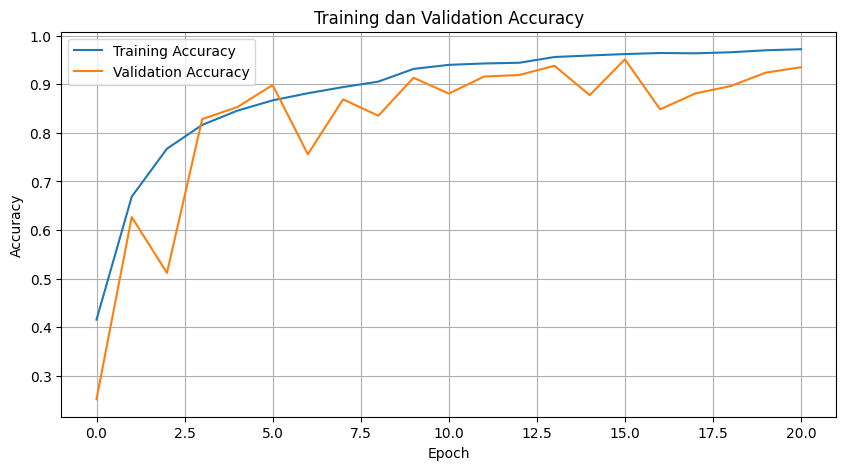

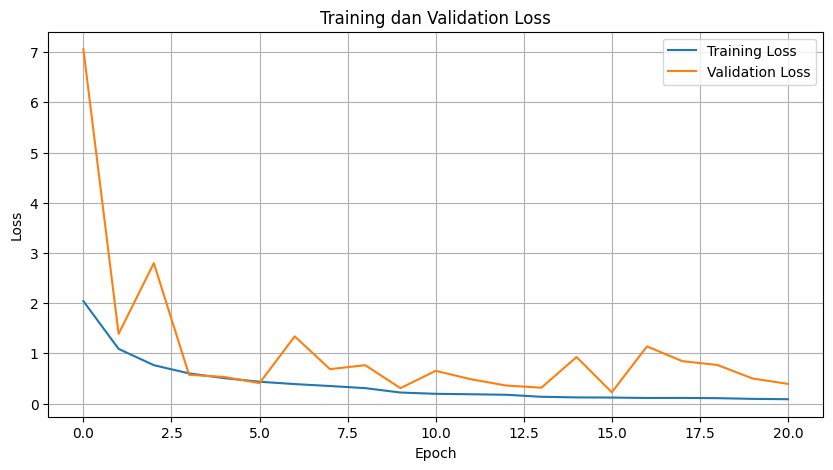

In [9]:
loss, accuracy = model.evaluate(test_generator)
print("Loss :", loss)
print("Accuracy :", accuracy)

# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training dan Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Konversi Model

In [10]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting u

In [11]:
# =====================
# 1. SavedModel
# =====================
model.export('saved_model/model_tanaman')
print("SavedModel tersimpan!")

# =====================
# 2. TF-Lite
# =====================
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model/model_tanaman')
tflite_model = converter.convert()

with open('model_tanaman.tflite', 'wb') as f:
    f.write(tflite_model)
print("TF-Lite tersimpan!")

# =====================
# 3. TFJS (pakai command line, hindari import tensorflowjs)
# =====================
!pip install tensorflowjs --quiet

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    saved_model/model_tanaman \
    tfjs_model/

print("TFJS tersimpan!")

Saved artifact at 'saved_model/model_tanaman'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  137320310063184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310064720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310066640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310064336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310064144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310065680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310066256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310066448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310068176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320310068368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137320

## Inference (Optional)

Saving TomatoEarlyBlight6.JPG to TomatoEarlyBlight6.JPG


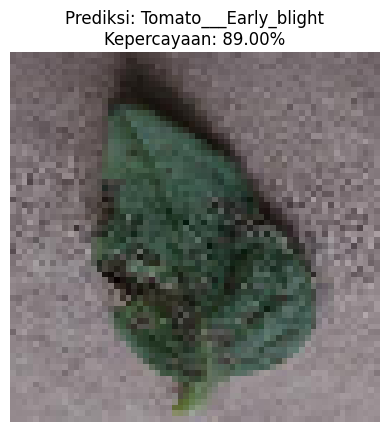

Prediksi  : Tomato___Early_blight
Confidence: 89.00%


In [13]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

# Load TF-Lite model
interpreter = tf.lite.Interpreter(model_path='/content/model_tanaman.tflite')
interpreter.allocate_tensors()

# Input & output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Class names dari generator
class_names = list(train_generator.class_indices.keys())

# Fungsi inference TF-Lite
def predict_tflite(img_path):
    # Load dan preprocess gambar
    img = load_img(img_path, target_size=(64, 64))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

    # Set input tensor
    interpreter.set_tensor(input_details[0]['index'], img_array)

    # Jalankan inferensi
    interpreter.invoke()

    # Ambil output
    output = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = class_names[np.argmax(output)]
    confidence = np.max(output) * 100

    # Tampilkan hasil
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prediksi: {predicted_class}\nKepercayaan: {confidence:.2f}%')
    plt.show()

    print(f"Prediksi  : {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

# Upload gambar dan prediksi
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

predict_tflite(img_path)